# 第5章 Matplotlib可视化：共享单车租赁分析

## 数据简介
Capital Bikeshare 记录了每天的租车情况。本章使用 UCI Bike Sharing 的日表，覆盖 2011—2012 年，共 731 行、16 列。
一行是一整天的汇总，租车量的单位是“次”，不是独立用户人数。

[数据集与许可](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) · [DOI](https://doi.org/10.24432/C5W894)。作者 Hadi Fanaee-T，CC BY 4.0；详见 `data/SOURCES.md`。

我们先看看：**一天通常会发生多少次租车？**

在 VS Code 中选择课程根目录 `.venv` 解释器，按顺序运行。数据保存在本章 `data/day.csv`，课堂无需联网下载。


## 环境与数据（Setup）
路径设置沿用本课程约定；临时探索请放在课程根目录 `tmp/`。

In [1]:
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    CHAPTER = cwd.parent
elif cwd.name == "Chapter5 - Matplotlib可视化":
    CHAPTER = cwd
else:
    CHAPTER = cwd / "Chapter5 - Matplotlib可视化"
assert CHAPTER.is_dir(), "请从本章notebooks目录、本章目录或课程根目录运行"
DATA = CHAPTER / "data"
OUTPUTS = CHAPTER / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

# Windows / macOS 常见中文字体；缺失字体时按顺序尝试。
font_names = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next(name for name in ["Microsoft YaHei", "PingFang SC", "SimHei", "Heiti TC", "Noto Sans CJK SC"] if name in font_names)
plt.rcParams["font.sans-serif"] = [chinese_font]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 11

### 读取数据：每天租了多少次车？

先看几天的租车记录。cnt 表示当天的总租车次数，路径变量 DATA 已在 Notebook 开头设置。

In [3]:
bike = pd.read_csv(DATA / "day.csv", parse_dates=["dteday"])
bike = bike.sort_values("dteday").reset_index(drop=True)
print(bike.shape)
print(bike[["cnt"]].head(7))

(731, 16)
    cnt
0   985
1   801
2  1349
3  1562
4  1600
5  1606
6  1510


前七行中的 985、801、1349 等数值分别表示一天的租车次数。仅看几行还难以判断通常的租车水平，接下来画出全部 731 天的分布。

In [4]:
# 先核对观察单位；检查不改变或删减样本。
assert bike.shape == (731, 16)
assert bike["dteday"].is_unique
assert bike["dteday"].diff().dropna().eq(pd.Timedelta(days=1)).all()
assert not bike.isna().any().any()
assert bike["cnt"].eq(bike["casual"] + bike["registered"]).all()
print("731 个连续日期，无缺失；总租车量 = 两类租车量之和。")

731 个连续日期，无缺失；总租车量 = 两类租车量之和。


## 直方图与绘图流程
### 一天通常租多少次？

### 第一张图：创建画布，画出分布

第一步 subplots 建画布和坐标系；第二步 hist 接收原始日租车量，自动完成分箱计数。

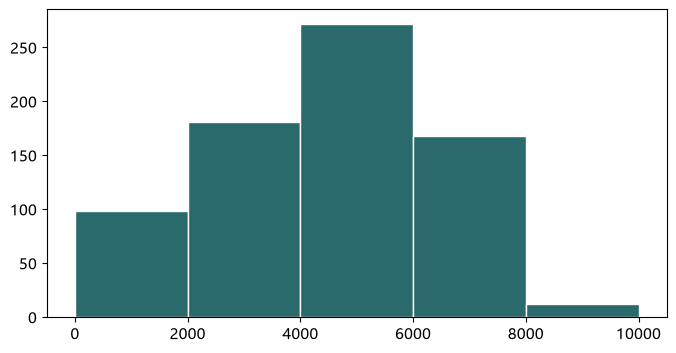

In [5]:
bin_edges = [0, 2000, 4000, 6000, 8000, 10000]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bike["cnt"], bins=bin_edges,
        color="#2B6A6C", edgecolor="white")
plt.show()

### 继续装饰：标题、单位、刻度

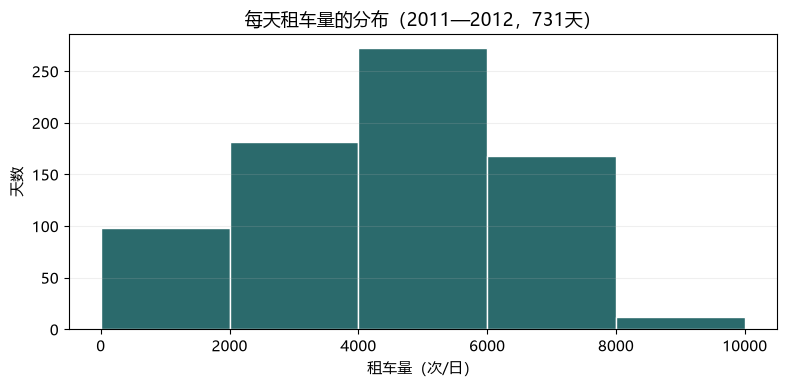

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bike["cnt"], bins=bin_edges,
        color="#2B6A6C", edgecolor="white")
ax.set_title("每天租车量的分布（2011—2012，731天）")
ax.set_xlabel("租车量（次/日）")
ax.set_ylabel("天数")
ax.set_xticks(bin_edges)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

五个区间的天数依次为 **98、181、272、168、12**，合计 731。最大一箱是 `[4000, 6000)`，272 天；这是本样本的频数事实。

In [7]:
counts, edges = np.histogram(bike["cnt"], bins=bin_edges)
pd.DataFrame({"左边界": edges[:-1], "右边界": edges[1:], "天数": counts})

,左边界,右边界,天数
0,0,2000,98
1,2000,4000,181
2,4000,6000,272
3,6000,8000,168
4,8000,10000,12


### bins 对照：只改变分箱数量

同样的 731 个值，共用横纵轴范围。这里用整数指定分箱数量，而不是手写分箱边界。

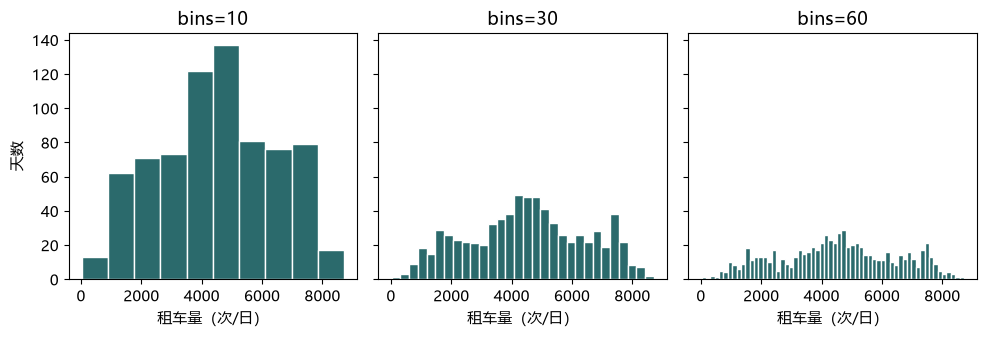

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5),
                         sharex=True, sharey=True)
for ax, bins in zip(axes, [10, 30, 60]):
    ax.hist(bike["cnt"], bins=bins,
            color="#2B6A6C", edgecolor="white")
    ax.set(title=f"bins={bins}", xlabel="租车量（次/日）")
axes[0].set_ylabel("天数")
fig.tight_layout()
plt.show()

箱数少会合并细节；箱数多会出现更细碎的起伏。数据没有改变，不能把分箱造成的变化当作新的事实。

### density 对照：面积才代表比例

为便于读数，两图都把同一列除以 1000，单位改成千次/日；仍然是同一组记录。

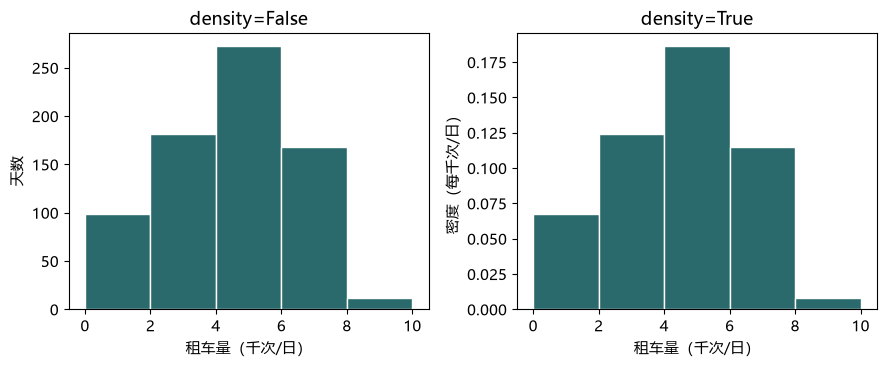

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, density in zip(axes, [False, True]):
    ax.hist(bike["cnt"] / 1000, bins=np.array(bin_edges) / 1000,
            density=density, color="#2B6A6C", edgecolor="white")
    ax.set(title=f"density={density}", xlabel="租车量（千次/日）")
axes[0].set_ylabel("天数")
axes[1].set_ylabel("密度（每千次/日）")
fig.tight_layout()
plt.show()

最高一箱宽度为 2：频数是 272，密度是 $272/(731\times2)\approx0.186$，面积约为 0.372，即 37.2%。密度柱高不是概率。

### 工作日与非工作日，租车量有何不同？

分布图没有区分日类型。要比较工作日与非工作日，可用 workingday：1 表示既非周末又非节假日，0 表示其他日子。先求各组均值。

              mean  size
workingday              
0           4330.2   231
1           4584.8   500


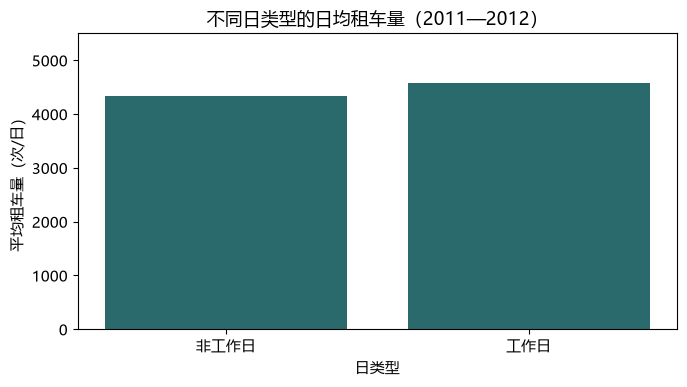

In [10]:
work_summary = bike.groupby("workingday")["cnt"].agg(["mean", "size"])
work_labels = ["非工作日", "工作日"]
print(work_summary.round(1))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(work_labels, work_summary["mean"], color="#2B6A6C")
ax.set(title="不同日类型的日均租车量（2011—2012）",
       xlabel="日类型", ylabel="平均租车量（次/日）", ylim=(0, 5500))
fig.tight_layout()
plt.show()

非工作日有 231 天，日均约 4330 次；工作日有 500 天，日均约 4585 次。两组天数不同，比较总次数会混入样本天数的影响。

### bar 与 hist：两种柱子的含义

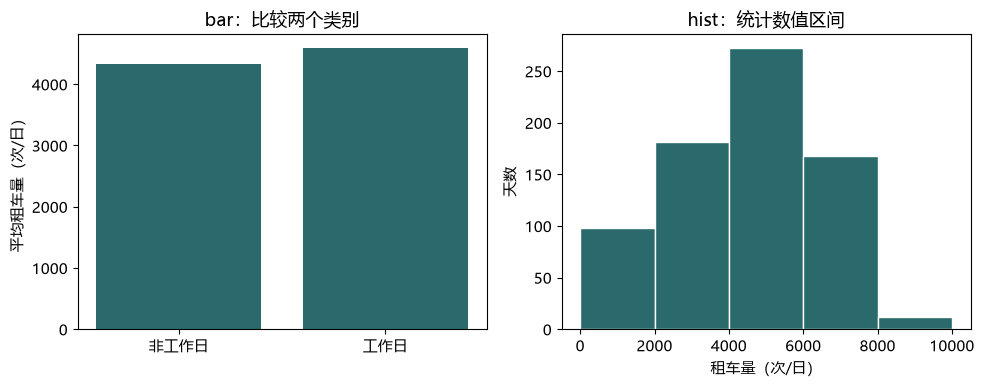

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(work_labels, work_summary["mean"], color="#2B6A6C")
axes[0].set(title="bar：比较两个类别", ylabel="平均租车量（次/日）")
axes[1].hist(bike["cnt"], bins=bin_edges,
             color="#2B6A6C", edgecolor="white")
axes[1].set(title="hist：统计数值区间", xlabel="租车量（次/日）", ylabel="天数")
fig.tight_layout()
plt.show()

左边输入“类别与算好的均值”，每根柱子对应一类日子；右边输入原始 cnt，自动分箱，每根柱子对应一个租车量区间。

**练习**：回答课件的三个问题。

<details><summary>检查思路</summary>均值接近不能推出每日值接近，也不能推出用户构成相同。sum 得到样本期总租车次数，单位为次，受各组天数影响。</details>

### 租车量随时间如何变化？

前面的分布和均值没有显示时间顺序。要看租车量何时高、何时低，需要用日期 dteday 作横轴，并按日期排序。

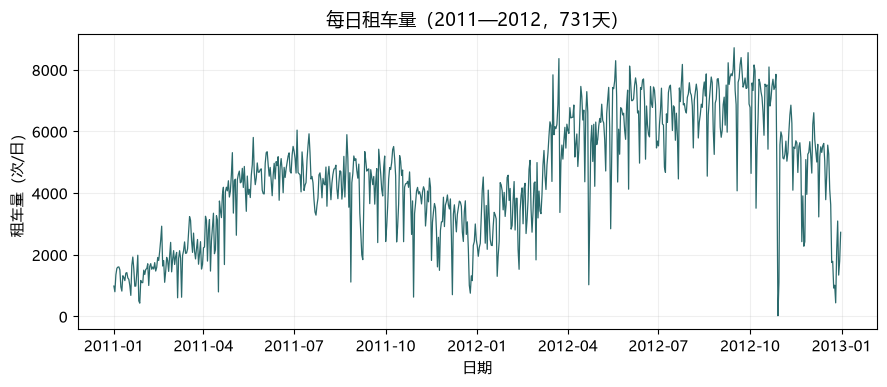

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bike["dteday"], bike["cnt"],
        color="#2B6A6C", linewidth=0.9)
ax.set(title="每日租车量（2011—2012，731天）",
       xlabel="日期", ylabel="租车量（次/日）")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

横轴是日期，纵轴仍是 cnt；连线表示相邻日期。两年中都有起伏，单个高低点的原因不能只凭这张图认定。

### 每天波动很大，怎样看清月度变化？

每日曲线起伏较多，可以先看每个月的平均水平。resample("MS") 按月分组，mean() 求月内日均值，得到 24 个点。

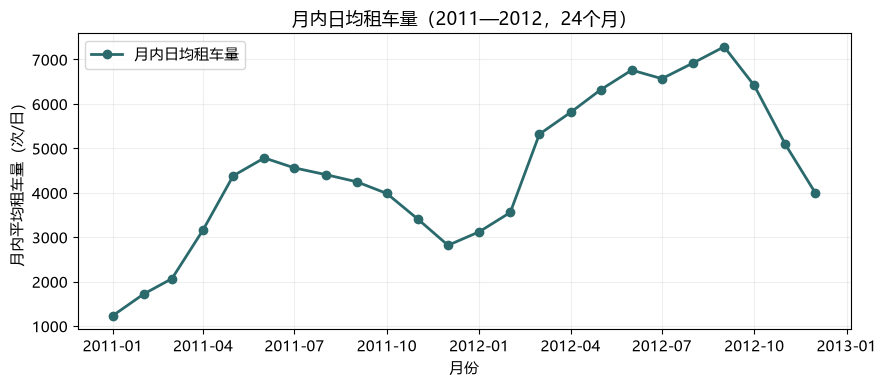

In [13]:
monthly = bike.set_index("dteday").resample("MS")["cnt"].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly, color="#2B6A6C",
        marker="o", linewidth=2, label="月内日均租车量")
ax.set(title="月内日均租车量（2011—2012，24个月）",
       xlabel="月份", ylabel="月内平均租车量（次/日）")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

marker="o" 标出 24 个月；label 提供图例文字，legend() 显示图例。月均值减少每日波动，不能读作月度总次数。

### 样式对照：只取原表前七天

用前七天的租车记录观察线条样式。每幅只改变一个参数，便于对应代码与效果。

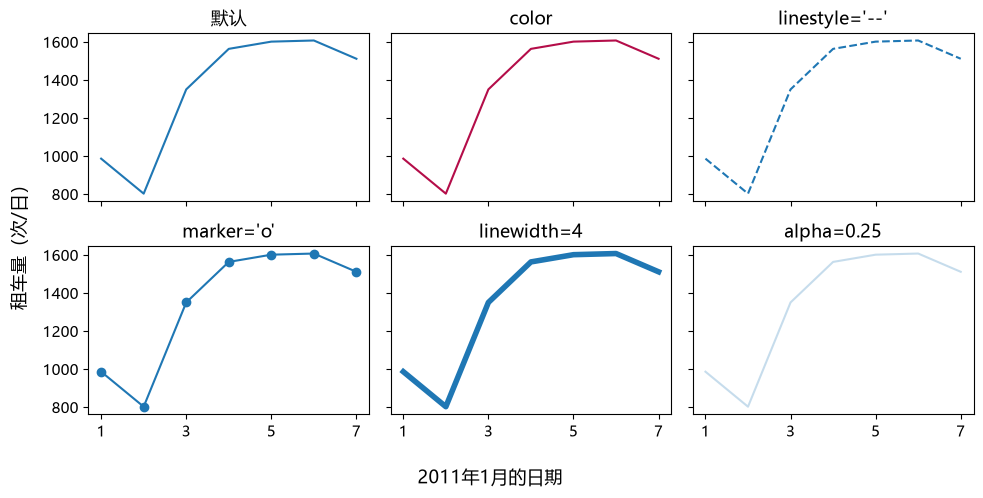

In [14]:
week = bike.head(7)
styles = [{}, {"color": "#B40D49"}, {"linestyle": "--"},
          {"marker": "o"}, {"linewidth": 4}, {"alpha": 0.25}]
titles = ["默认", "color", "linestyle='--'", "marker='o'",
          "linewidth=4", "alpha=0.25"]
fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey=True)
for ax, style, title in zip(axes.flat, styles, titles):
    ax.plot(week["dteday"].dt.day, week["cnt"], **style)
    ax.set(title=title, xticks=[1, 3, 5, 7])
fig.supxlabel("2011年1月的日期")
fig.supylabel("租车量（次/日）")
fig.tight_layout()
plt.show()

颜色、虚线、圆点、粗细、透明度分别由一个参数控制。实际画图时可以把这些参数组合起来；参数改变外观，不改变原始值。

### 两类用户的租车量如何变化？

总量的变化来自哪些用户？casual 记录临时用户租车次数，registered 记录注册用户租车次数；两类之和等于 cnt。分别画线可以比较各自的变化。

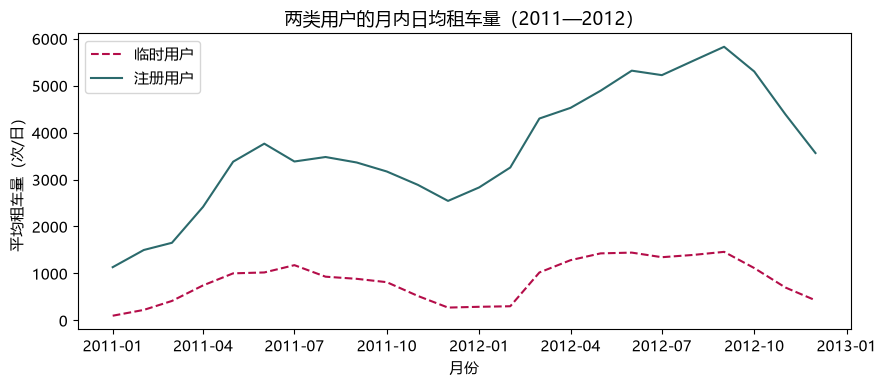

In [15]:
user_monthly = bike.set_index("dteday").resample("MS")[["casual", "registered", "cnt"]].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(user_monthly.index, user_monthly["casual"],
        color="#B40D49", linestyle="--", label="临时用户")
ax.plot(user_monthly.index, user_monthly["registered"],
        color="#2B6A6C", label="注册用户")
ax.set(title="两类用户的月内日均租车量（2011—2012）",
       xlabel="月份", ylabel="平均租车量（次/日）")
ax.legend()
fig.tight_layout()
plt.show()

每次 plot 增加一条线；实线与虚线也能区分类别。两条曲线仍来自同样的 24 个月，纵轴单位一致。

### 总量接近，用户构成也一样吗？

工作日与非工作日的日均总量接近，两类用户是否也如此？分别计算各组的临时、注册用户日均租车量，用并排的柱子比较。

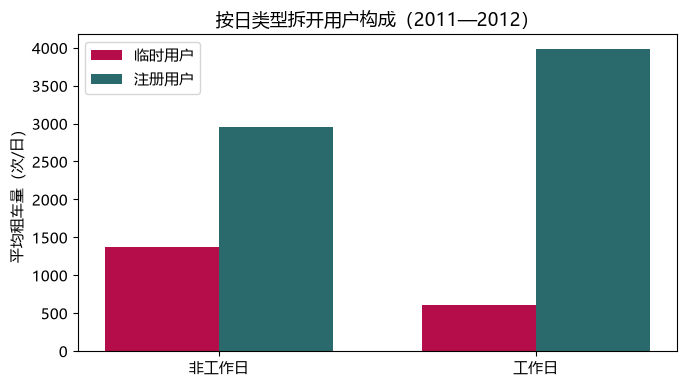

In [16]:
user_work = bike.groupby("workingday")[["casual", "registered"]].mean()
x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.18, user_work["casual"], width=0.36,
       color="#B40D49", label="临时用户")
ax.bar(x + 0.18, user_work["registered"], width=0.36,
       color="#2B6A6C", label="注册用户")
ax.set_xticks(x, work_labels)
ax.set(title="按日类型拆开用户构成（2011—2012）", ylabel="平均租车量（次/日）")
ax.legend()
fig.tight_layout()
plt.show()

临时用户：非工作日约 1371 次/日，工作日约 607；注册用户：约 2959 与 3978。总量接近可以掩盖构成差异；图本身不能证明出行目的。

### `fill_between`：两条边界之间填充

下层从 0 填到 registered，上层从 registered 填到 cnt。上下两层的厚度分别对应两类租车量。

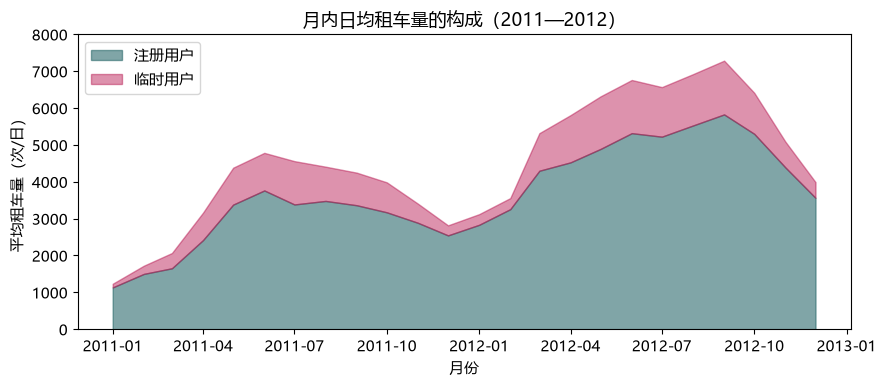

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(user_monthly.index, 0, user_monthly["registered"],
                color="#2B6A6C", alpha=0.6, label="注册用户")
ax.fill_between(user_monthly.index, user_monthly["registered"],
                user_monthly["cnt"], color="#B40D49", alpha=0.45, label="临时用户")
ax.set(title="月内日均租车量的构成（2011—2012）",
       xlabel="月份", ylabel="平均租车量（次/日）", ylim=(0, 8000))
ax.legend()
fig.tight_layout()
plt.show()

`fill_between`(x, y1, y2) 填充两条边界之间的区域；alpha 控制透明度。最上方边界是总量，上层厚度才是临时用户量。

### 天气暖和时，租车量会更高吗？

租车量的起伏是否与温度有关？用标准化温度 temp 与同一天的 cnt 配成一个点，观察二者的关系。temp 不是摄氏度。

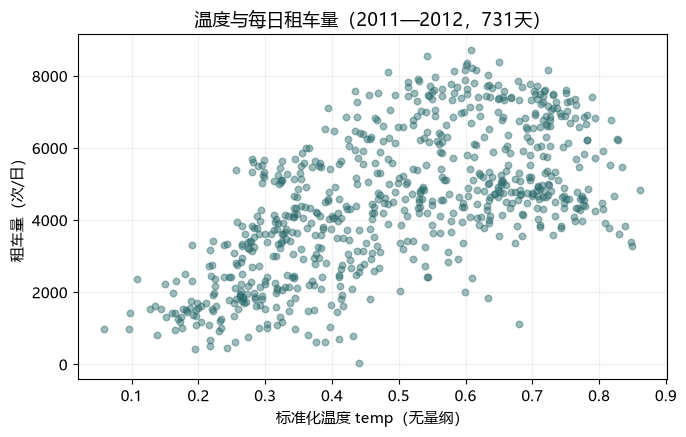

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(bike["temp"], bike["cnt"],
           color="#2B6A6C", alpha=0.45, s=22)
ax.set(title="温度与每日租车量（2011—2012，731天）",
       xlabel="标准化温度 temp（无量纲）", ylabel="租车量（次/日）")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

每个点代表一天。较暖的日子总体对应较高租车量，但同一温度附近仍有很大差异。alpha 减少重叠遮挡，s 控制点的面积。

### 相近温度下，两年的租车量一样吗？

相近温度下，租车量仍有很大差异，会不会与年份有关？用 yr 区分 2011（0）与 2012（1），以颜色和点形标记，横纵轴保持不变。

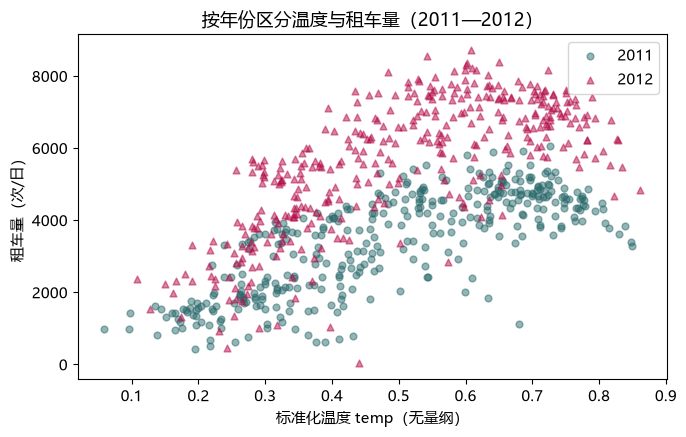

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for year, color, marker in [(0, "#2B6A6C", "o"), (1, "#B40D49", "^")]:
    part = bike[bike["yr"] == year]
    ax.scatter(part["temp"], part["cnt"], color=color,
               marker=marker, alpha=0.5, s=24, label=str(2011 + year))
ax.set(title="按年份区分温度与租车量（2011—2012）",
       xlabel="标准化温度 temp（无量纲）", ylabel="租车量（次/日）")
ax.legend()
fig.tight_layout()
plt.show()

2012 年的点群整体偏高；同一张无分组散点图混合了年份差异。分组展示有助于发现结构，但没有控制所有影响因素，也不能据此确定因果。

按全年计算，2011 年日均约 **3406 次**，2012 年约 **5600 次**。这是两个年份的描述性比较，不等于“年份”本身造成增长。

In [20]:
bike.groupby("yr")["cnt"].agg(["size", "mean"]).rename(index={0: 2011, 1: 2012}).round(1)

,size,mean
yr,,
2011,365,3405.8
2012,366,5599.9


### subplots：上下两图共享日期轴

2, 1 表示两行一列。axes[0] 在上，axes[1] 在下；sharex=True 共享月份范围。

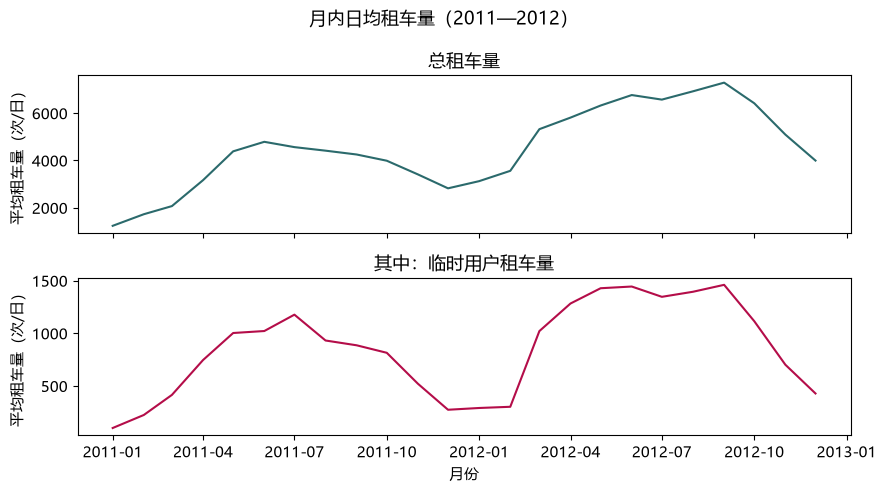

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(user_monthly.index, user_monthly["cnt"], color="#2B6A6C")
axes[0].set(title="总租车量", ylabel="平均租车量（次/日）")
axes[1].plot(user_monthly.index, user_monthly["casual"], color="#B40D49")
axes[1].set(title="其中：临时用户租车量", xlabel="月份", ylabel="平均租车量（次/日）")
fig.suptitle("月内日均租车量（2011—2012）")
fig.tight_layout()
plt.show()

上图隐藏重复的日期文字，下图保留；`tight_layout()` 调整间距。两幅图纵轴范围不同，比较数值时仍要读刻度。

### 用 pandas 快速画出两条曲线

DataFrame.plot 默认把索引作为横轴、每列作为一条线。返回的仍是 Matplotlib 坐标系。

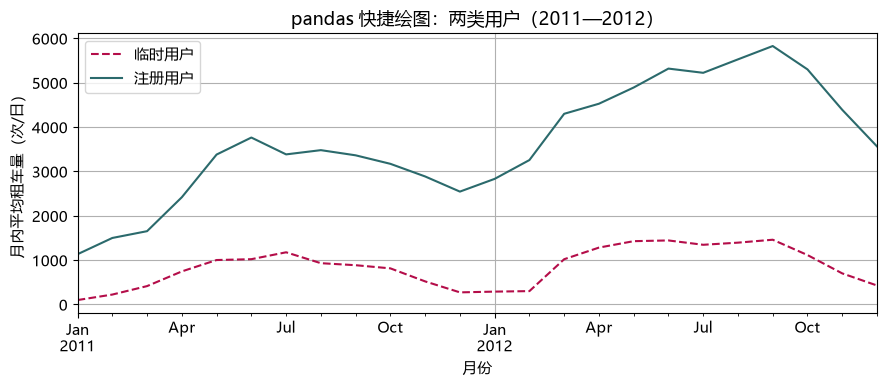

In [22]:
ax = user_monthly[["casual", "registered"]].plot(
    figsize=(9, 4), color=["#B40D49", "#2B6A6C"],
    style=["--", "-"], grid=True)
ax.set(title="pandas 快捷绘图：两类用户（2011—2012）",
       xlabel="月份", ylabel="月内平均租车量（次/日）")
ax.legend(["临时用户", "注册用户"])
fig = ax.figure
fig.tight_layout()
plt.show()

这与前面的两条用户曲线使用完全相同的数据。探索时可以使用 pandas 快捷接口，需要细调时继续调用 ax 的方法。

其他快捷形式也使用同一张表：`bike["cnt"].hist(bins=30)`；`work_summary["mean"].plot(kind="bar")`。默认直方图纵轴是频数。

### 综合图（上）：先放时间与类别比较

axes[行, 列] 从 0 开始。先完成上面一行；接着运行下一页代码，填满同一张画布。

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(monthly.index, monthly, color="#2B6A6C")
axes[0, 0].set(title="月内日均租车量", xlabel="月份", ylabel="次/日")
tick_dates = monthly.index[[0, 6, 12, 18, 23]]
axes[0, 0].set_xticks(tick_dates, tick_dates.strftime("%Y-%m"))
axes[0, 1].bar(work_labels, work_summary["mean"], color="#2B6A6C")
axes[0, 1].set(title="日类型比较", ylabel="平均租车量（次/日）")
plt.close(fig)  # 暂不显示，下一单元格继续完成

### 综合图（下）：再放分布与关系

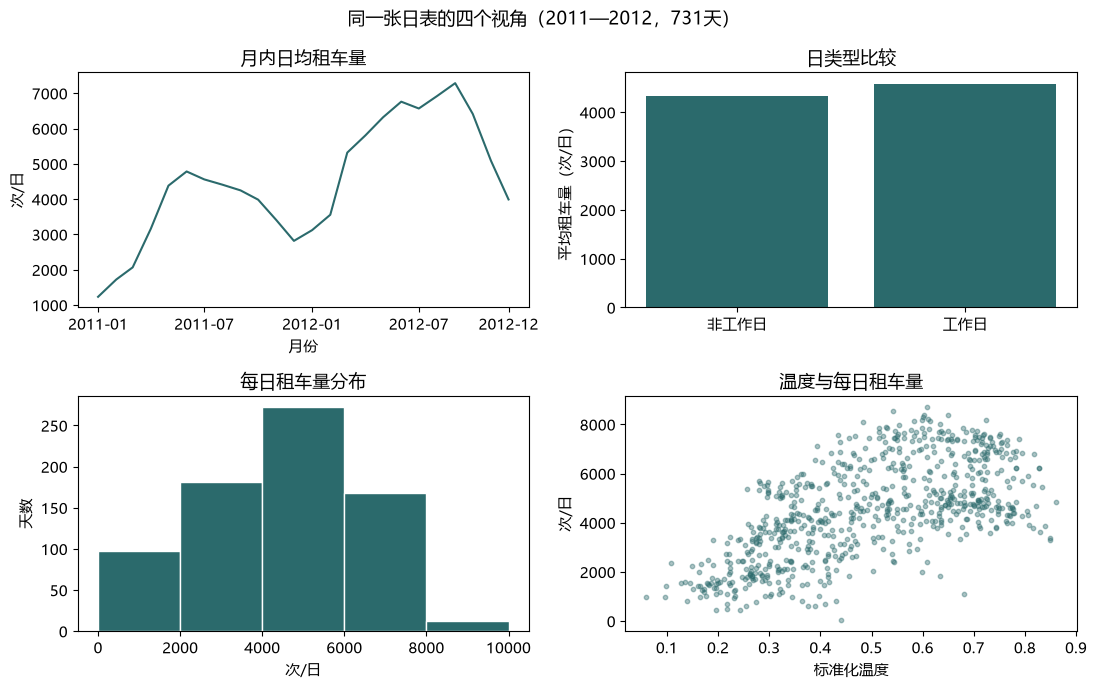

In [24]:
axes[1, 0].hist(bike["cnt"], bins=bin_edges,
                color="#2B6A6C", edgecolor="white")
axes[1, 0].set(title="每日租车量分布", xlabel="次/日", ylabel="天数")
axes[1, 1].scatter(bike["temp"], bike["cnt"],
                   color="#2B6A6C", alpha=0.4, s=10)
axes[1, 1].set(title="温度与每日租车量", xlabel="标准化温度", ylabel="次/日")
fig.suptitle("同一张日表的四个视角（2011—2012，731天）")
fig.tight_layout()
display(fig)  # 显示前一单元格创建、现已完成的画布

左上是时间，右上是类别，左下是分布，右下是关系。四幅图来自同一张表，但统计单位与纵轴含义并不完全相同。

### 保存图片：导出刚才的四宫格

fig 保留对刚才画布的引用。文件名后缀决定 PNG 或 PDF；输出都放在本章 outputs/。

In [25]:
fig.savefig(OUTPUTS / "bike_report.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUTS / "bike_report.pdf", bbox_inches="tight")

## 检查（Checks）
1. 只有一处 `pd.read_csv`；所有图形来自同一个 `bike`。
2. 直方图频数相加为 731；分组样本数为 231 + 500 = 731。
3. 月份汇总为 24 行；用户类型之和等于总量。
4. 导出图与 Notebook 的四宫格一致，坐标轴含义没有丢失。

In [26]:
assert counts.sum() == len(bike)
assert work_summary["size"].sum() == len(bike)
assert len(monthly) == 24
assert np.allclose(user_monthly["casual"] + user_monthly["registered"], user_monthly["cnt"])
density, density_edges = np.histogram(bike["cnt"] / 1000,
                                     bins=np.array(bin_edges) / 1000, density=True)
assert np.isclose((density * np.diff(density_edges)).sum(), 1)
print("分箱、分组、月度汇总、构成与密度面积核对通过。")

分箱、分组、月度汇总、构成与密度面积核对通过。


## 继续练习（Next Steps）
1. 湿度较高时租车量是否不同？用 `hum * 100` 与 `cnt` 画散点图，一点代表一天。
2. 不同天气类别的日均租车量有何差异？`weathersit` 中 1 为晴/少云，2 为雾/多云，3 为小雨雪类。先列出各组样本天数，再画日均租车量。
3. 给 `monthly` 添加全体 731 天的日均值水平线。它不一定等于 24 个月均值的简单平均，因为月份天数不同。

在每幅图下面写一句观察，再写一句不能由这张图直接推出的结论。

In [27]:
# 在这里完成练习；提示和参考答案可在下方展开。

<details><summary>练习1：湿度散点图</summary>

```python
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(bike["hum"] * 100, bike["cnt"], color="#2B6A6C", alpha=0.4)
ax.set(xlabel="湿度（%）", ylabel="租车量（次/日）", title="湿度与租车量（2011—2012）")
fig.tight_layout()
plt.show()
```
这是关系图，不能仅据此判断湿度变化的因果效应。
</details>

<details><summary>练习2：天气分组与样本数</summary>

```python
weather = bike.groupby("weathersit")["cnt"].agg(["mean", "size"])
display(weather)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["晴/少云", "雾/多云", "小雨雪类"], weather["mean"], color="#2B6A6C")
ax.set(ylabel="平均租车量（次/日）", title="天气类别比较（2011—2012）")
fig.tight_layout()
plt.show()
```
三个天气组分别有 463、247、21 天；类别 4 未出现在本日表，不能补成“0 次租车”的柱子。各组年份、季节等构成可能不同。
</details>

<details><summary>练习3：在月均曲线上添加日均参考线</summary>

```python
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly, label="月内日均租车量", color="#2B6A6C")
ax.axhline(bike["cnt"].mean(), linestyle="--", color="gray", label="全样本日均值")
ax.set(xlabel="月份", ylabel="平均租车量（次/日）", title="月均曲线与全样本日均值")
ax.legend()
fig.tight_layout()
plt.show()
```
</details>

### 来源与口径备注
- `data/day.csv` 为官方日表原样保存；`data/UCI_Readme.txt` 保留压缩包说明。
- [UCI 数据页](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) 与压缩包 Readme 的温度换算、季节编码说明存在差异。本章不还原摄氏度、不按 season 解码；保留 `temp` 标准化尺度。
- Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. DOI: 10.24432/C5W894，CC BY 4.0。
- Fanaee-T, H. and Gama, J. (2013). *Event labeling combining ensemble detectors and background knowledge*. DOI: 10.1007/s13748-013-0040-3。
- 本章为描述性教学探索，没有建立因果模型；不将这两年的历史样本当作当前运营水平。